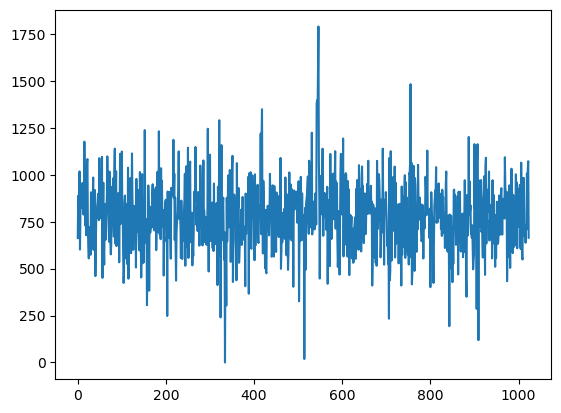

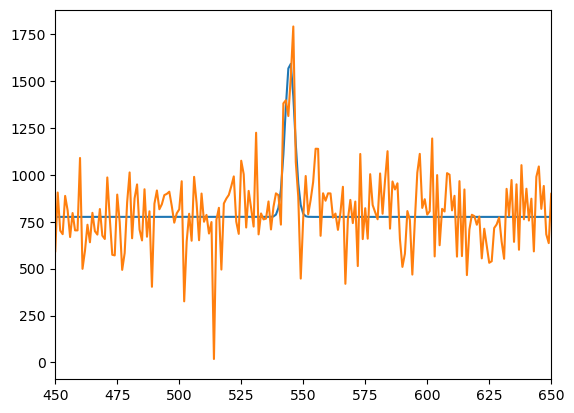


Calibration results:
(0.277, 389.1419056712507, 0.5348951280419711, 5.13, 544.6140589485534)


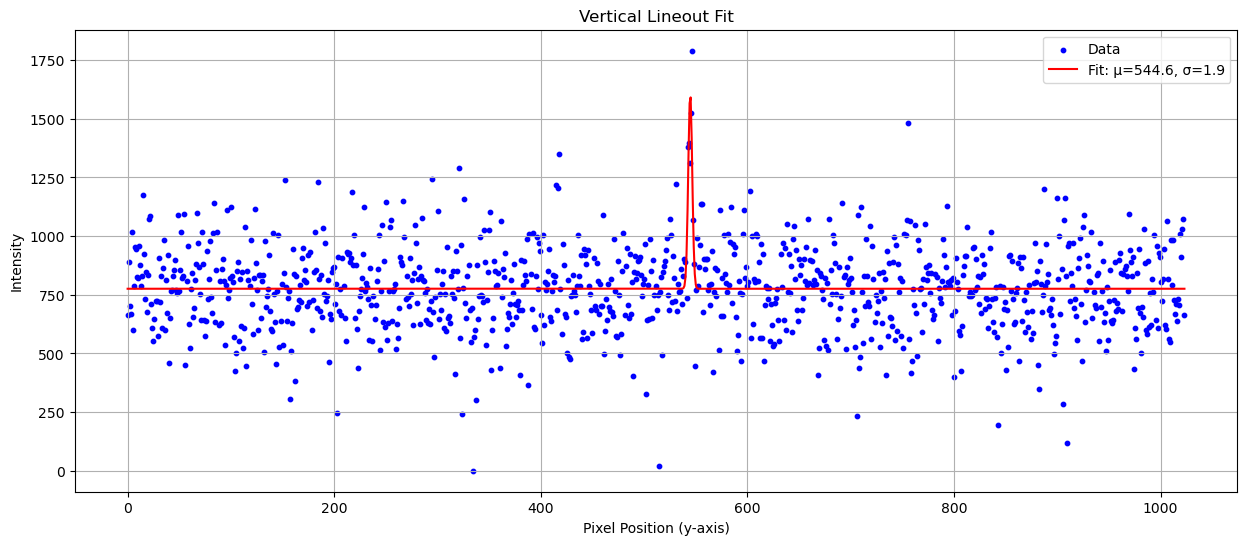

In [77]:
# Import necessary modules
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from pyhdf.SD import SD, SDC
from matplotlib import pyplot as plt


# Gaussian function for fitting
def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

#preprocessing function 
def preprocess(file_path):
     # Open HDF file and read data
    hdf = SD(file_path, SDC.READ)
    try:
        sds = hdf.select("Streak_array")
        data = sds.get()
        
        # Handle 3D data 
        if data.ndim == 3:
            frame_idx = np.argmax(np.max(data, axis=(1, 2)))
            data = data.astype(float)
            data = np.squeeze(data[0,:,:] - data[1,:,:])

        return data
    finally:
        hdf.end()

#use file path to categorize the type of file
def categorize_file(file_path):
    lower_name = file_path.lower()
    if 'iaw' in lower_name:
        if 'ccd' in lower_name:
            type = 'iaw_ccd'
        elif 'ross' in lower_name:
            type = 'iaw_ross'
    elif 'epw' in lower_name:
        if 'ccd' in lower_name:
            type = 'epw_ccd'
        elif 'ross' in lower_name:
            type = 'epw_ross'
    return type


# dispersions coresponding to a central wavelenght and grating
def calibrations_table(type,grating,cw):
    if type =="iaw_ccd":
        cali = {
            (1800, 701): 0.00482,
            (1800, 707): 0.00481,
            (2160, 522): 0.00437,
            (2160, 525): 0.00448,
            (2400, 351): 0.00446,
            (2400, 520): 0.00368,
            (2400, 522): 0.00365,
            (3600, 264): 0.00286,
            (3600, 265): 0.00284  }
    elif type == "epw_ccd":
        cali = {
            (150, 260) : 0.274,
            (150, 351) : 0.275,
            (150, 527) : 0.277,
            (600, 320) : 0.0678,
            (600, 685) : 0.0669,
            (1200, 180) : 0.0331  }
    elif type == "iaw_ross":
            cali = {
            (1800, 365): 0.00984,
            (1800, 366): 0.00986,
            (1800, 520): 0.00902,
            (1800, 524): 0.00902,
            (2160, 522): 0.00686,
            (2160, 525): 0.00683,
            (2400, 351): 0.00700,
            (2400, 520): 0.00575,
            (2400, 522): 0.00571,
            (3600, 264): 0.00446,
            (3600, 265): 0.00449,
            (3600, 351): 0.00378  }
    elif type == "epw_ross":
        cali = {
            (150, 263) : 0.4156,
            (150, 351) : 0.4153,
            (150, 527) : 0.4143,
            (600, 320) : 0.1019,
            (1200, 190) : 0.05069,
            (1200, 180) : 0.05026    }
    # first check if there is a match 
    if (grating, cw) in cali: 
        return cali[(grating,cw)]
    #get all cw values and dispersions for the specified grating 
    cw_dispersions = []
    for key, disp in cali.items():
        g ,c = key
        if g == grating: 
            cw_dispersions.append((c,disp))
    # Calculate absolute differences between provided cw and existing cw values
    differences = [(abs(cw - c_val), c_val, disp) for c_val, disp in cw_dispersions]
    # Find the minimum difference
    min_diff = min(diff[0] for diff in differences)
    
    # Check if minimum difference is within tolerance (<=20)
    if min_diff > 20:
        raise ValueError(f"No valid dispersion found for grating {grating} and cw {cw}. Closest match is {min_diff} away (max allowed: 20)")
    
    # Collect all dispersions with the minimum difference
    closest_dispersions = [disp for diff, c_val, disp in differences if diff == min_diff]
    
    # Return average dispersion if multiple closest matches
    return sum(closest_dispersions) / len(closest_dispersions)
    
    #return dispersion

def calibration(file_path,date, grating,cw,telescope,alaser):
    data = preprocess(file_path)
    type = categorize_file(file_path)
    #find max coordinates
    y_max, x_max = np.unravel_index(np.argmax(data), data.shape)
    #if type is ross/temportal sum over the horizontal axis to get the vertical lineout, opposite for ccd/spectral type
    if 'ross' in type:
        lineout = np.mean(data, axis = 1)
        mag_values = {
        "refractive": {"magE": 1.7, "magI": 0.87},
        "reflective": {"magE": 2.3, "magI": 4.5}
    }
        
    elif 'ccd' in type:
        lineout = np.sum(data, axis = 0)
        mag_values = {
        "refractive": {"magE": 1.7, "magI": 0.87},
        "reflective": {"magE": 5.13, "magI": 2.88}
    }

    # Telescope magnifications with error handling
    if telescope not in ["refractive", "reflective"]:
        raise ValueError("Telescope type must be 'refractive' or 'reflective'")
    
    if 'iaw' in type:
        species = "magI"
    else:
        species = "magE"

    magnification = mag_values[telescope][species]

     # Gaussian fitting lineout
    #normalize data 
    lineout = ((lineout - min(lineout))/(max(lineout)-min(lineout))) * max(lineout)
    x = np.arange(lineout.size)        
    initial_guess = (
        np.max(lineout),
        550,
        #np.mean(x[lineout>0.5*np.max(lineout)]),
        1.0,
        np.max([np.min(lineout),0])
    )
    params, _ , info, msg, irt = curve_fit(gaussian, x, lineout, p0=initial_guess,full_output=True)
    A, mu, sigma, offset = params
    fit_A = params[0]
    fit_B = params[1]
    fit_y = gaussian(x, fit_A,fit_B,params[2], params[3])
    fwhm = 2.3548 * sigma

    # Sanity checks
    # Amplitude check should be at least % 50 of the max value 
    if A < 0.5 * np.max(lineout):
        print(f"Warning: Amplitude {A:.2f} is less than 50% of the maximum lineout value {np.max(lineout):.2f}. Expected ~  ≥ {0.5*np.max(lineout):.2f}")
    #Peak position check mu should be in the range of 384 to 640 pixels
    if not (384 <= mu <= 640):
        print(f"Peak position (mu) {mu:.2f} is not centerd. Expected range (384, 640).")
    # Sigma check, it must be positive and resonable 
    if  sigma <= 0:
        print(f"Invalid sigma: sigma={sigma:.2f} (must be positive)")
    elif sigma < 0.5:
        print(f"Sigma too small: sigma={sigma:.2f}")
    elif sigma > 20:
        print(f"Sigma too large: sigma={sigma:.2f}")

    #use calibrations table and inputs to get the dispersion, then use dispersion, and params from gauss to get offset and stdv
    dispersion = calibrations_table(type,grating,cw)
    #offset =  alaser - dispersion * mu
    offset = (alaser - dispersion* mu) - (alaser - cw)
    stdev = sigma * dispersion
    tcc = mu

    #plots to verify gaussian fit 
    #plot of lineout 
    plt.plot(lineout)
    plt.show()
    #plot of the fit focussing on the range 450 to 650
    plt.plot(fit_y)
    plt.plot(lineout)
    plt.xlim([450,650])
    plt.show()
    
    fig, (ax1) = plt.subplots(1,figsize=(15, 6))
    
    # Vertical lineout plot
    x_ver = np.arange(len(lineout))
    ax1.scatter(x_ver, lineout, s=10, label='Data', color='blue')
    ax1.plot(x_ver, gaussian(x_ver, *params), 
            label=f'Fit: μ={params[1]:.1f}, σ={params[2]:.1f}', 
            color='red')
    ax1.set_title('Vertical Lineout Fit')
    ax1.set_xlabel('Pixel Position (y-axis)')
    ax1.set_ylabel('Intensity')
    ax1.legend()
    ax1.grid(True)

    return dispersion , offset, stdev, magnification, tcc


if __name__ == "__main__":
    try:
        results = calibration(
            file_path="2w_532cw_50umslit_EPWCCD.hdf",
            date = 2024_06_09,
            grating=150,
            cw = 540,
            telescope="reflective",
            alaser = 532,
        )
        print("\nCalibration results:")
        print(results)
    except Exception as e:
        print(f"Error in processing: {str(e)}")